# MIMO_MTS test on ZCU208
---

The following results were captured when looping back all 8 DACs to 8 ADCs through equal-length cables.

### Preparation from a PYNQ 3.0.1 image:

Run installation script: `./pynq_llrf/install.sh`.

In [1]:
%cd /home/xilinx/jupyter_notebooks/pynq_llrf/

/home/xilinx/jupyter_notebooks/pynq_llrf


In [3]:
import numpy as np
import time
from mimo_mts.overlay import MimoMtsOverlay

%load_ext autoreload
%autoreload 2

In [4]:
ol = MimoMtsOverlay(config='MIMO_IQ_ZCU208')

Interrupt xpm_cdc_gen_1/dest_pulse created with number 2


In [5]:
ol

< MimoMtsOverlay >:
{ 'bitfile_name': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/overlays/zcu208/mimo_mts_iq.bit'),
  'board': Board(name='ZCU208',
                 active_adc_tiles=15,
                 active_dac_tiles=15,
                 max_adc_sampling_rate=5000000000.0,
                 max_dac_sampling_rate=7000000000.0,
                 converters_per_tile=2,
                 adc_ref_tile=225,
                 dac_ref_tile=230),
  'clk104_tcs': { 'lmk_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMK04828_500M_CLKin0.tcs'),
                  'lmxadc_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs'),
                  'lmxdac_tcs': PosixPath('/home/xilinx/jupyter_notebooks/pynq_llrf/mimo_mts/utils/clk104/LMX2594_4G.tcs')},
  'ioc': {'decimation': 16},
  'rfdc': { 'adc_decimation_factor': 1,
            'dac_interpolation_factor': 2,
            'mixer': { 'adc_mixer_mode': 1,
     

In [6]:
ol.clk104

< CLK104Config >:
  === LMK04828: ===
part            :    LMK04828B
SYSREF_FREQ     :        2.498 MHz
OSCout_FREQ     :      160.009 MHz
CLKin0_FREQ     :      499.640 MHz
CLKin1_FREQ     :       10.000 MHz
CLKin2_FREQ     :       76.800 MHz
CLKout0_FREQ    :      499.640 MHz
CLKout1_FREQ    :        2.498 MHz
CLKout2_FREQ    :      499.640 MHz
CLKout3_FREQ    :        2.498 MHz
CLKout4_FREQ    :      499.640 MHz
CLKout5_FREQ    :        2.498 MHz
CLKout6_FREQ    :      499.640 MHz
CLKout7_FREQ    :        2.498 MHz
CLKout8_FREQ    :      499.640 MHz
CLKout9_FREQ    :        2.498 MHz
CLKout10_FREQ   :      499.640 MHz
CLKout11_FREQ   :        2.498 MHz
CLKout12_FREQ   :      499.640 MHz
CLKout13_FREQ   :        2.498 MHz
CLKin_SEL_MODE  :       CLKin0
VCO_MUX         :         VCO0
  === LMX2594 ADC: ===
part            :      LMX2594
Fosc_FREQ       :      499.640 MHz
FoutA_FREQ      :     3997.120 MHz
FoutB_FREQ      :     3997.120 MHz
Fpd_FREQ        :      249.820 MHz
Fvco_FREQ 

In [7]:
f_dsp_mhz = 250
trig_period = 125e6  # cycles of f_dsp_mhz

print(f"fclk0_mhz: {f_dsp_mhz} MHz")
print(f"trigger frequency: { f_dsp_mhz * 1e6 / trig_period:.2f} Hz")

fclk0_mhz: 250 MHz
trigger frequency: 2.00 Hz


# Configure trigger



In [8]:
ol.rf_control.register_map.trig_period = trig_period
ol.rf_control.register_map.trig_sel = 0
ol.rf_control.register_map.trig_delay = 0
ol.rf_control.register_map.trig_divide = 1
ol.rf_control.register_map.dac_enable = 1
ol.rf_control.register_map.pulse_length = 0xfff

## Test IRQ

Note: Jupyter notebook refresh time of ~300ms limits the testing to 3Hz

In [9]:
async def wait_for_irq():
    irq = ol.write_done_irq
    t0 = time.perf_counter()
    while True:
        await irq.wait()
        t1 = time.perf_counter()
        print(f"IRQ!, time since last: {t1-t0:.6f} s")

In [10]:
import asyncio
loop = asyncio.get_event_loop()
task = loop.create_task(wait_for_irq())
try:
    loop.run_until_complete(task)
except KeyboardInterrupt:
    print("KeyboardInterrupt received. Stopping the loop.")
    task.cancel()

IRQ!, time since last: 0.000599 s
IRQ!, time since last: 0.430020 s
IRQ!, time since last: 0.930813 s
IRQ!, time since last: 1.431628 s
IRQ!, time since last: 1.932436 s
IRQ!, time since last: 2.433259 s
IRQ!, time since last: 2.934089 s
IRQ!, time since last: 3.434879 s
IRQ!, time since last: 3.935705 s
IRQ!, time since last: 4.436512 s
IRQ!, time since last: 4.937322 s
IRQ!, time since last: 5.438144 s
IRQ!, time since last: 5.938949 s
IRQ!, time since last: 6.439757 s
IRQ!, time since last: 6.940577 s
IRQ!, time since last: 7.441378 s
IRQ!, time since last: 7.942199 s
IRQ!, time since last: 8.443004 s
KeyboardInterrupt received. Stopping the loop.


# Generate Waveforms for Loopback

This overlay uses a single waveform memory that is broadcast to multiple DAC tiles.
The DAC accepts a stream of interleaved I/Q samples.

In [11]:
fs = ol.adc_sampling_rate
fs_ghz = fs / 1e9
start = 1196 # start of the signal
print(f'Fs: {fs_ghz} GHz. RF loop back latency: {start/fs_ghz} ns')

Fs: 4.0 GHz. RF loop back latency: 299.0 ns


In [12]:
t = np.arange(ol.dac_player.size) / fs_ghz
f_c = 0.2  # GHz
amp = 2**15 - 1
dac_wfm = np.exp(1j * 2 * np.pi * f_c * t) * amp

dac_wfm = dac_wfm[::2]  # interleave IQ
pulse_length_ns = 20
n_samples = int(pulse_length_ns * fs_ghz / 2)
dac_wfm[n_samples:] = 0

ol.write_dac_complex(dac_wfm)

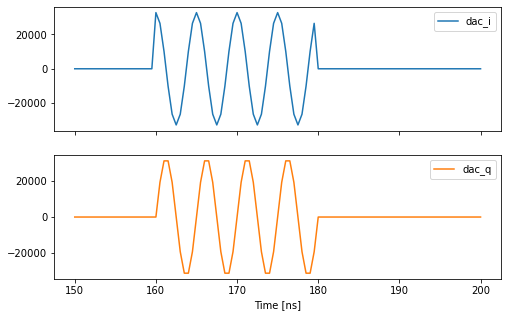

In [13]:
df_dac = ol.capture_dac_iq_df()
df_dac[150:200].plot(subplots=True, figsize=(8, 5));

Loop back dac1-7 to adc 1-7, check waveforms

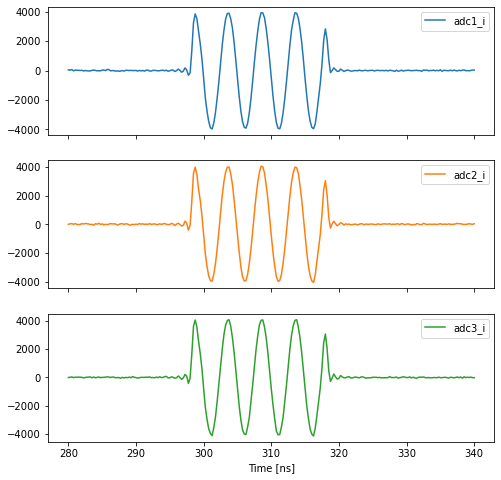

In [14]:
df_adc = ol.capture_adc_iq_df()
cols = [f'adc{ch}_i' for ch in range(1, 4)]
df_adc[cols][280:340].plot(subplots=True, figsize=(8, 8));

### Verify Alignment Stability

In [17]:
n_samples = 1024
for i in range(3):
    x = df_adc['adc1_i'].iloc[start:start+n_samples].astype(np.float32)
    y = df_adc['adc3_i'].iloc[start:start+n_samples].astype(np.float32)
    x_corr = np.correlate(x, y, mode='full')
    lags = np.arange(-n_samples+1, n_samples)
    delay = lags[np.argmax(x_corr)]
    print(f'Iteration {i} : Cross-correlation delay = {delay} samples')
    assert delay == 0, 'Cross-correlation delay is not zero'

Iteration 0 : Cross-correlation delay = 0 samples
Iteration 1 : Cross-correlation delay = 0 samples
Iteration 2 : Cross-correlation delay = 0 samples


### Set DAC baseband waveform as DC, reset mixer

In [18]:
dac_i = np.ones(ol.dac_player.size//2, dtype=np.int16) * 32767
dac_q = np.zeros_like(dac_i)
ol.write_dac_iq_buf(dac_i, dac_q)

### Change DAC mixer setting with NCO to 125 MHz

In [19]:
ol.set_dac_mixer(125)

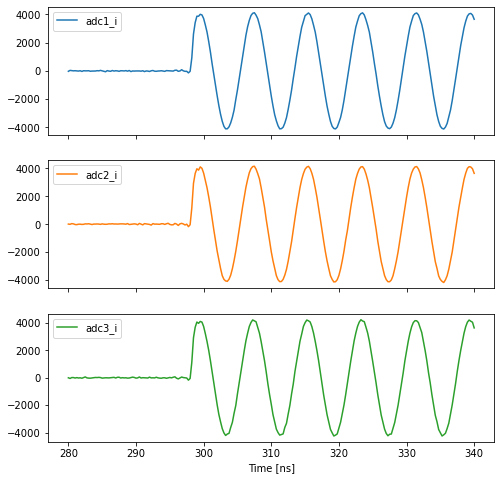

In [20]:
df_adc = ol.capture_adc_iq_df()
cols = [f'adc{ch}_i' for ch in range(1, 4)]
df_adc[cols][280:340].plot(subplots=True, figsize=(8, 8));

###  Change DAC mixer setting with NCO to 500 MHz

In [22]:
ol.set_dac_mixer(500)
ol.set_adc_mixer(0)

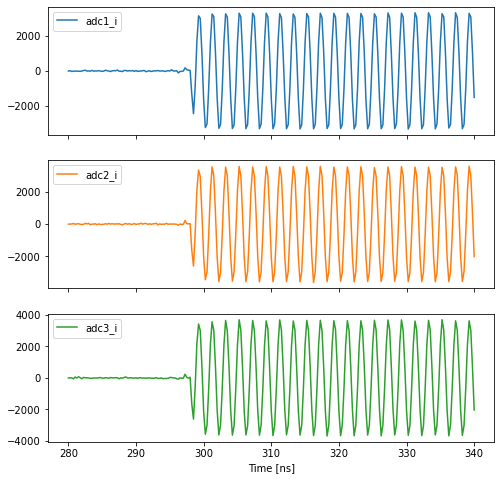

In [23]:
df_adc = ol.capture_adc_iq_df()
cols = [f'adc{ch}_i' for ch in range(1, 4)]
df_adc[cols][280:340].plot(subplots=True, figsize=(8, 8));

###  Change both DAC/ADC mixer setting, check base-band (DSP) waveforms after loopback

In [30]:
def get_dsp_waveform(ol=ol):
    """
    Get the DSP waveform from the ADC buffer.
    Average ADC data by 2 samples, as the same to the LLRF DSP,
    equivalent to a low pass filter to get base band signal.
    """
    darray_i, darray_q = ol.capture_adc_iq_buf()
    cdata = darray_i + 1j*darray_q
    return cdata.reshape(4, -1, 16).mean(axis=2)

In [31]:
ol.rf_control.register_map.dac_enable.pulse_enable=1
ol.rf_control.register_map.pulse_length=1000

In [32]:
ol.set_dac_mixer(125)
ol.set_adc_mixer(-125)

In [33]:
from mimo_mts.utils.plot import plot_complex_wfm_stack

note dac0 is connected to scope, so adc0 is disconnected

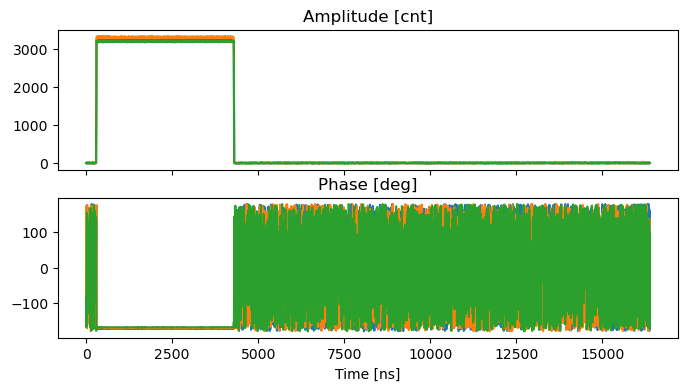

In [34]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[1:], fs=fs/16, mode='ap')

In [35]:
ol.set_dac_mixer(500)
ol.set_adc_mixer(-500)

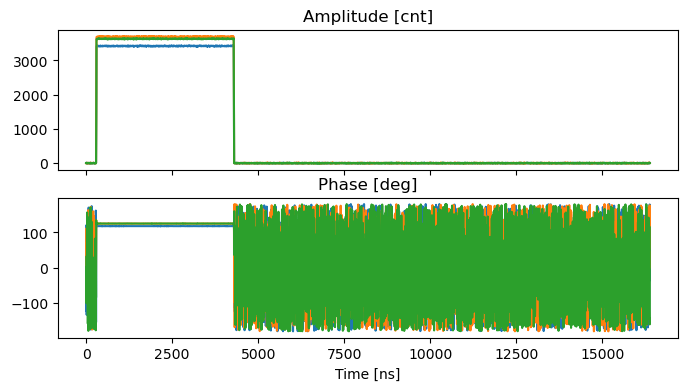

In [36]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[1:], fs=fs/16, mode='ap')

In [37]:
ol.set_dac_mixer(-3000, nyquist=2)
ol.set_adc_mixer(3000, nyquist=2)

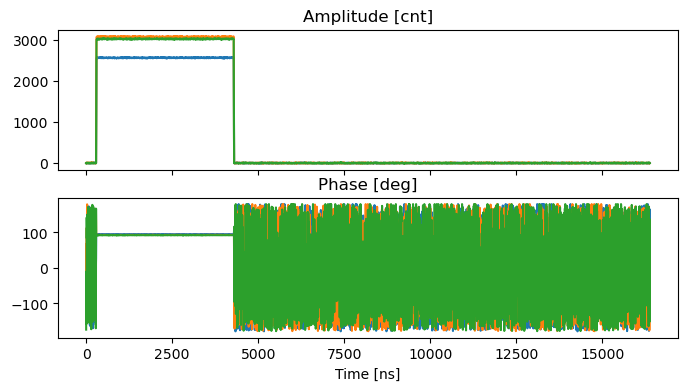

In [38]:
cdata_dsp = get_dsp_waveform()
plot_complex_wfm_stack(cdata_dsp[1:], fs=fs/16, mode='ap')

In [39]:
ol.dac_blocks[0,0].IncSincFIR=2

In [40]:
v = getattr(ol.rf_control.register_map, 'pulse_length')
v

Register(value=1000)